# What are we forecasting?

Forecast Close Price

# Load Data

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv(
    "../data/processed/wti_timeseries_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)
df.head()

,Close,High,Low,Open,Volume,daily_return,volatility_20,MA20,MA50,MA100,drawdown
Date,,,,,,,,,,,
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985,NaN,NaN,NaN,NaN,NaN,0.000000
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995,0.016391,NaN,NaN,NaN,NaN,0.000000
2021-06-03,68.809998,69.400002,68.190002,68.760002,351367,-0.000291,NaN,NaN,NaN,NaN,-0.000291
2021-06-04,69.620003,69.760002,68.330002,68.910004,326250,0.011772,NaN,NaN,NaN,NaN,0.000000
2021-06-07,69.230003,70.000000,68.930000,69.519997,365621,-0.005602,NaN,NaN,NaN,NaN,-0.005602


# Handle Missing Values

In [5]:
#1. Check for missing values
print(df.isnull().sum())

Close             0
High              0
Low               0
Open              0
Volume            0
daily_return      1
volatility_20    20
MA20             19
MA50             49
MA100            99
drawdown          0
dtype: int64


In [6]:
#2. For forecasting
df = df.dropna()

# Train-Test Split

In [7]:
train = df.iloc[:-252]
test = df.iloc[-252:]

# Visualize Train/Test

In [8]:
import matplotlib.pyplot as plt

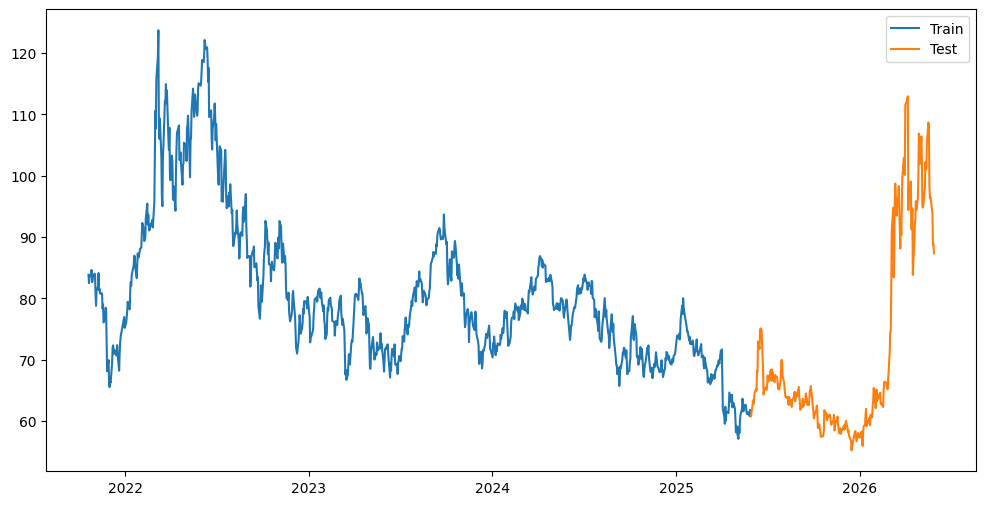

In [9]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train["Close"])
plt.plot(test.index, test["Close"])

plt.legend(["Train","Test"])

# Stationarity Check

In [10]:
from statsmodels.tsa.stattools import adfuller

In [11]:
result = adfuller(train["Close"])

print(result[1])

0.4216094434660461


# Baseline Forecast

In [13]:
# Naive Forecast
# Tomorrow = Today

test["naive_forecast"] = (
    test["Close"].shift(1)
)

# Forecast Metrics Module

In [15]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

1. ARIMA

In [21]:
from src.forecasting_metrics import (
    fit_arima, evaluate_forecast
)

model = fit_arima(
    train["Close"]
)

/home/hakurrrpunk/Documents/github/oil-price-trend-analysis/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/hakurrrpunk/Documents/github/oil-price-trend-analysis/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/hakurrrpunk/Documents/github/oil-price-trend-analysis/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


2. Forecast

In [22]:
forecast = model.forecast(
    steps=len(test)
)

/home/hakurrrpunk/Documents/github/oil-price-trend-analysis/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


3. Evaluate ARIMA

In [23]:
evaluate_forecast(
    test["Close"],
    forecast
)        

{'MAE': 11.11407719445292, 'RMSE': np.float64(18.15187223667898)}

4. Visual Comparision

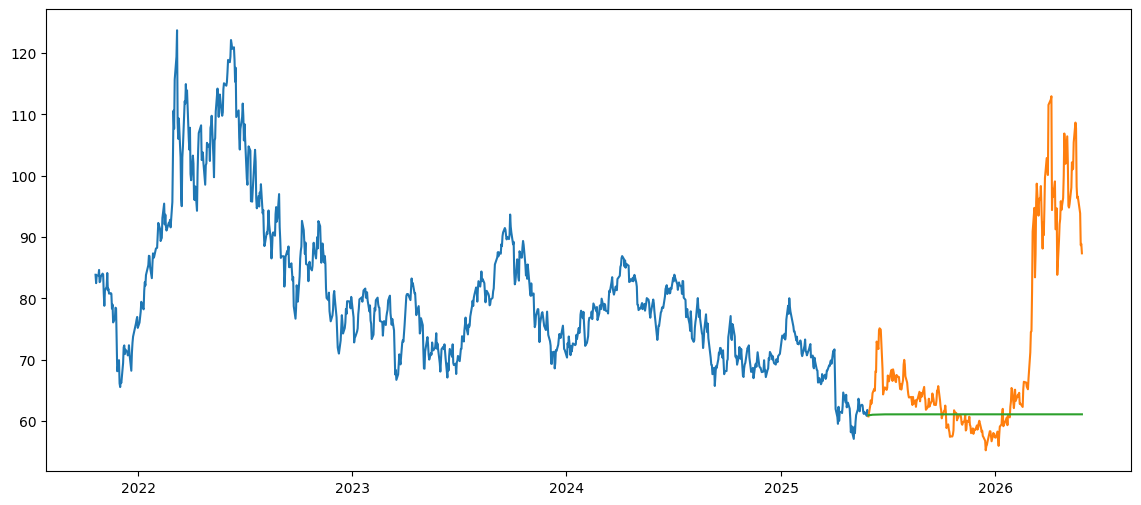

In [24]:
plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train["Close"]
)

plt.plot(
    test.index,
    test["Close"]
)

plt.plot(
    test.index,
    forecast
)